# 09 - CelebA StarGAN 人脸属性编辑

第四周任务 7.1-7.3：使用一个 StarGAN v1 模型完成黑发、金发、棕发、性别和年龄属性编辑，并用 FID 与 Inception Score 评估生成质量。

## 1. 方法

生成器将图像与目标属性向量拼接，经过下采样、残差块和上采样得到编辑结果。判别器同时执行真伪判别和属性分类。训练损失由 WGAN-GP 对抗损失、属性分类损失和循环重建损失组成。

In [2]:
import json
import random
import time
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
from torch.optim import Adam
from torch.utils.data import DataLoader
from torchvision.utils import make_grid, save_image

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == 'face_effects':
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))

from face_effects.stargan import (
    CelebAAttributes, Discriminator, Generator, celeba_transform,
    evaluate_quality, initialize_weights, make_attribute_targets, train_epoch,
)

config = json.loads((PROJECT_ROOT / 'face_effects/stargan_config.json').read_text())
work_dir = PROJECT_ROOT / 'work_dirs/stargan_celeba'
work_dir.mkdir(parents=True, exist_ok=True)

seed = config['seed']
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device)
print(json.dumps(config, ensure_ascii=False, indent=2))

device: cuda
{
  "dataset_root": "data/CelebA",
  "attributes": [
    "Black_Hair",
    "Blond_Hair",
    "Brown_Hair",
    "Male",
    "Young"
  ],
  "image_size": 128,
  "batch_size": 16,
  "num_workers": 4,
  "epochs": 10,
  "max_steps": 100000,
  "max_training_hours": 2.0,
  "generator_lr": 0.0001,
  "discriminator_lr": 0.0001,
  "beta1": 0.5,
  "beta2": 0.999,
  "lambda_cls": 1.0,
  "lambda_rec": 10.0,
  "lambda_gp": 10.0,
  "n_critic": 5,
  "evaluation_images": 5000,
  "seed": 42
}


## 2. CelebA 数据

严格使用官方训练/测试划分。图像先中心裁剪为正方形，再缩放到 128 x 128；训练集额外使用随机水平翻转。

In [3]:
dataset_root = PROJECT_ROOT / config['dataset_root']
attributes = config['attributes']
train_set = CelebAAttributes(
    dataset_root, attributes, 'train',
    celeba_transform(config['image_size'], train=True),
)
test_set = CelebAAttributes(
    dataset_root, attributes, 'test',
    celeba_transform(config['image_size']),
)
loader_options = {
    'batch_size': config['batch_size'],
    'num_workers': config['num_workers'],
    'pin_memory': device.type == 'cuda',
    'persistent_workers': config['num_workers'] > 0,
}
train_loader = DataLoader(train_set, shuffle=True, drop_last=True, **loader_options)
test_loader = DataLoader(test_set, shuffle=False, **loader_options)
print(f'train={len(train_set):,}, test={len(test_set):,}, attributes={attributes}')

train=162,770, test=19,962, attributes=['Black_Hair', 'Blond_Hair', 'Brown_Hair', 'Male', 'Young']


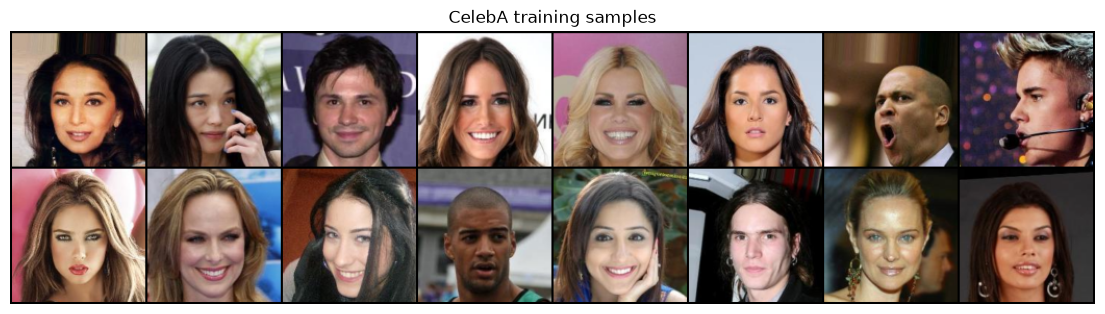

first image: 109599.jpg {'Black_Hair': 1, 'Blond_Hair': 0, 'Brown_Hair': 0, 'Male': 0, 'Young': 1}


In [4]:
images, labels, filenames = next(iter(train_loader))
grid = make_grid(images[:16], nrow=8, normalize=True, value_range=(-1, 1))
plt.figure(figsize=(14, 4))
plt.imshow(grid.permute(1, 2, 0))
plt.axis('off')
plt.title('CelebA training samples')
plt.show()
print('first image:', filenames[0], dict(zip(attributes, labels[0].int().tolist())))

## 3. 模型训练

默认配置为单张 RTX 3080 设置 2 小时硬上限，每个 epoch 保存一次检查点。需要更充分训练时，可提高配置中的 `max_training_hours`、`epochs` 和 `max_steps`。

In [6]:
generator = Generator(len(attributes)).to(device)
discriminator = Discriminator(config['image_size'], len(attributes)).to(device)
generator.apply(initialize_weights)
discriminator.apply(initialize_weights)
generator_optimizer = Adam(
    generator.parameters(), lr=config['generator_lr'],
    betas=(config['beta1'], config['beta2']),
)
discriminator_optimizer = Adam(
    discriminator.parameters(), lr=config['discriminator_lr'],
    betas=(config['beta1'], config['beta2']),
)
print(f'G parameters: {sum(p.numel() for p in generator.parameters()):,}')
print(f'D parameters: {sum(p.numel() for p in discriminator.parameters()):,}')

G parameters: 8,430,531
D parameters: 44,762,048


In [5]:
history = []
global_step = 0
deadline = time.monotonic() + config['max_training_hours'] * 3600

for epoch in range(1, config['epochs'] + 1):
    result = train_epoch(
        generator, discriminator, train_loader,
        generator_optimizer, discriminator_optimizer, device,
        lambda_cls=config['lambda_cls'], lambda_rec=config['lambda_rec'],
        lambda_gp=config['lambda_gp'], n_critic=config['n_critic'],
        start_step=global_step, max_steps=config['max_steps'],
        deadline=deadline, log_interval=0, epoch=epoch, show_progress=True,
    )
    global_step += result['steps']
    result.update(epoch=epoch, global_step=global_step)
    history.append(result)
    checkpoint = {
        'epoch': epoch, 'global_step': global_step, 'config': config,
        'generator': generator.state_dict(),
        'discriminator': discriminator.state_dict(),
        'generator_optimizer': generator_optimizer.state_dict(),
        'discriminator_optimizer': discriminator_optimizer.state_dict(),
    }
    torch.save(checkpoint, work_dir / 'latest.pth')
    (work_dir / 'training_history.json').write_text(
        json.dumps(history, indent=2), encoding='utf-8'
    )
    print(result)
    if global_step >= config['max_steps'] or time.monotonic() >= deadline:
        print('Reached configured training limit; latest checkpoint saved.')
        break

Epoch 1: 100%|██████████| 10173/10173 [15:59<00:00, 10.60batch/s, D=-2.4360, G=-1.5734, step=10173]


{'d_loss': -2.4360154373806555, 'g_loss': -1.5733706970189056, 'steps': 10173, 'epoch': 1, 'global_step': 10173}


Epoch 2: 100%|██████████| 10173/10173 [15:57<00:00, 10.63batch/s, D=-1.1658, G=-1.0455, step=20346]


{'d_loss': -1.165815936975129, 'g_loss': -1.0455213342017564, 'steps': 10173, 'epoch': 2, 'global_step': 20346}


Epoch 3: 100%|██████████| 10173/10173 [15:57<00:00, 10.63batch/s, D=-0.8527, G=-0.1850, step=30519]


...

{'d_loss': -0.5417943632794651, 'g_loss': 0.02417967101465636, 'steps': 10173, 'epoch': 6, 'global_step': 61038}


Epoch 7: 100%|██████████| 10173/10173 [16:00<00:00, 10.60batch/s, D=-0.5030, G=0.0281, step=71211]


{'d_loss': -0.5030472442204902, 'g_loss': 0.02806110231237857, 'steps': 10173, 'epoch': 7, 'global_step': 71211}


Epoch 8:  51%|█████     | 5153/10173 [08:04<07:52, 10.63batch/s, D=-0.4827, G=0.2353, step=76364]


{'d_loss': -0.4826748935281999, 'g_loss': 0.2353277709009578, 'steps': 5153, 'epoch': 8, 'global_step': 76364}
Reached configured training limit; latest checkpoint saved.


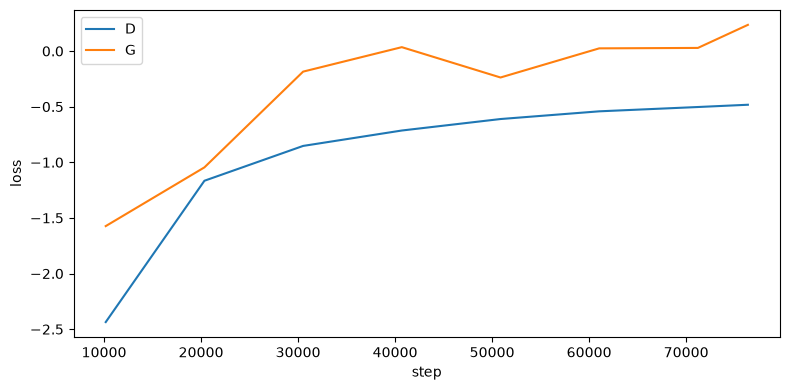

In [6]:
if history:
    plt.figure(figsize=(8, 4))
    plt.plot([item['global_step'] for item in history], [item['d_loss'] for item in history], label='D')
    plt.plot([item['global_step'] for item in history], [item['g_loss'] for item in history], label='G')
    plt.xlabel('step')
    plt.ylabel('loss')
    plt.legend()
    plt.tight_layout()
    plt.savefig(work_dir / 'training_losses.png', dpi=160)
    plt.show()

## 4. 属性编辑结果

每行从左到右依次为原图、Black_Hair、Blond_Hair、Brown_Hair、Male、Young。发色目标会互斥设置，Male 与 Young 则切换原标签。

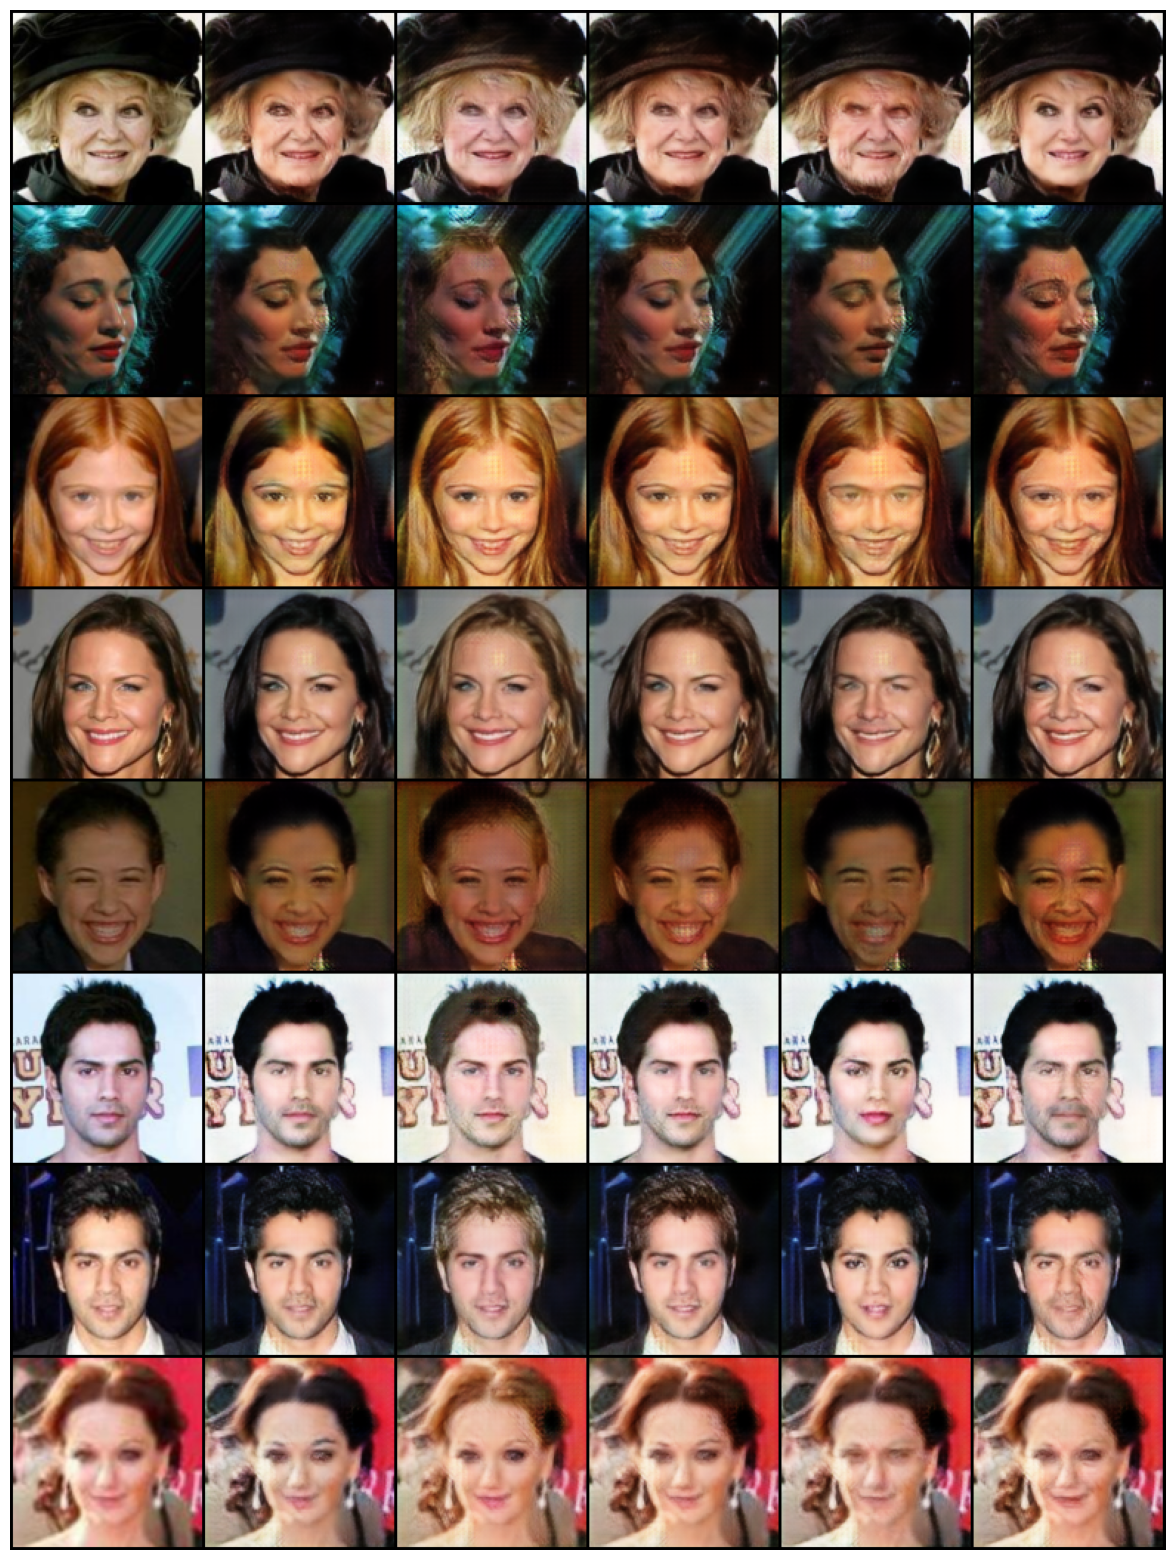

In [7]:
checkpoint_path = work_dir / 'latest.pth'
if not checkpoint_path.exists():
    raise FileNotFoundError('Run the training cell or provide work_dirs/stargan_celeba/latest.pth')
generator.load_state_dict(torch.load(checkpoint_path, map_location=device, weights_only=False)['generator'])
generator.eval()
real, labels, _ = next(iter(test_loader))
real, labels = real[:8].to(device), labels[:8].to(device)
with torch.inference_mode():
    variants = [generator(real, target) for target in make_attribute_targets(labels, attributes)]
translations = torch.stack([real, *variants], dim=1).flatten(0, 1).cpu()
grid = make_grid(translations, nrow=len(attributes) + 1, normalize=True, value_range=(-1, 1))
save_image(grid, work_dir / 'attribute_edits.png')
plt.figure(figsize=(15, 20))
plt.imshow(grid.permute(1, 2, 0))
plt.axis('off')
plt.show()

## 5. FID 与 Inception Score

FID 越低越好；IS 越高通常表示图像更清晰且更多样。两者基于 ImageNet Inception-v3，并不能完整衡量人脸属性是否编辑正确，因此同时保留上面的定性结果。首次运行会下载官方 Inception-v3 权重。

In [8]:
metrics = evaluate_quality(
    generator, test_loader, device, max_images=config['evaluation_images']
)
(work_dir / 'quality_metrics.json').write_text(
    json.dumps(metrics, indent=2), encoding='utf-8'
)
metrics

d:\InternProject\face-vision-lab\.venv\Lib\site-packages\torchvision\transforms\functional.py:1603: UserWarning: The default value of the antialias parameter of all the resizing transforms (Resize(), RandomResizedCrop(), etc.) will change from None to True in v0.17, in order to be consistent across the PIL and Tensor backends. To suppress this warning, directly pass antialias=True (recommended, future default), antialias=None (current default, which means False for Tensors and True for PIL), or antialias=False (only works on Tensors - PIL will still use antialiasing). This also applies if you are using the inference transforms from the models weights: update the call to weights.transforms(antialias=True).
  warnings.warn(


{'images': 5000,
 'fid': 9.245138101745965,
 'is_mean': 2.8219439926883263,
 'is_std': 0.08560536115599299}

## 6. 实验记录与实验结果

### 6.1 实验配置

| 项目 | 实际设置 |
|---|---|
| 运行设备 | CUDA |
| 数据集 | CelebA 官方划分：训练集 162,770 张，测试集 19,962 张 |
| 编辑属性 | Black_Hair、Blond_Hair、Brown_Hair、Male、Young |
| 输入尺寸 | 128 x 128 |
| Batch size | 16 |
| 学习率 | G/D 均为 0.0001 |
| 损失权重 | 分类 1.0、循环重建 10.0、梯度惩罚 10.0 |
| 判别器更新频率 | 每次迭代更新；生成器每 5 次迭代更新一次 |
| 参数量 | Generator 8,430,531；Discriminator 44,762,048 |
| 随机种子 | 42 |

### 6.2 训练记录

训练原计划执行 10 epochs，但按配置在 2 小时达到硬上限后正常停止并保存检查点。最终完成 7 个完整 epoch，第 8 个 epoch 完成 5,153/10,173 batches（51%），累计 **76,364 steps**，平均吞吐约 **10.6 batches/s**。最终记录的判别器损失为 **-0.4827**，生成器损失为 **0.2353**。

判别器损失从第 1 个 epoch 的 -2.4360 逐步收敛至约 -0.5，生成器损失从 -1.5734 上升并在 0 附近波动。WGAN-GP 的损失值不能像普通分类交叉熵一样直接解释为越小越好，但曲线没有出现持续发散，属性编辑图也表明模型已经学到有效映射。训练检查点、损失曲线与历史记录分别保存为 `latest.pth`、`training_losses.png` 和 `training_history.json`。

### 6.3 定量评估

在 CelebA 测试集随机目标属性编辑的 5,000 张生成图像上得到：

| 指标 | 结果 | 说明 |
|---|---:|---|
| FID | **9.2451** | 生成图像特征分布与真实测试图像较接近；该值仅在相同数据和预处理设置下可比 |
| Inception Score | **2.8219 ± 0.0856** | 反映一定的清晰度与多样性，但 ImageNet 分类特征对人脸属性编辑的解释能力有限 |
| 评估图像数 | **5,000** | 与配置中的 `evaluation_images` 一致 |

### 6.4 定性结果分析

- **发色编辑：** Black_Hair、Blond_Hair 和 Brown_Hair 三列在多数样本上呈现清晰、方向正确的颜色变化，同时基本保留姿态、表情和背景。帽子遮挡、暗光或原始头发区域较小时，颜色变化相对有限。
- **性别编辑：** Male 标签切换会改变胡须、眉眼、嘴唇与面部纹理。女性样本男性化后常出现胡须，男性样本女性化后嘴唇颜色和皮肤质感变化明显。
- **年龄编辑：** Young 标签按原标签反转。年长样本年轻化后皮肤更平滑、皱纹减少；年轻样本老化后出现皱纹、阴影和更粗糙的皮肤纹理。
- **身份保持：** 大多数结果仍可辨认出原身份，头部轮廓和背景保持稳定，但性别和年龄变化较强时会产生一定身份漂移。
- **主要伪影：** 部分结果在额头和皮肤区域出现规则网格纹理、局部色偏或过度平滑，低光照和侧脸样本更明显。这说明当前两小时训练已经获得可用效果，但尚未完全消除生成伪影。

### 6.5 实验结论

本实验完成了 CelebA 多属性 StarGAN 的训练、发色/性别/年龄编辑和 FID/IS 评估。模型在 2 小时预算内学习到了明确的属性控制能力，并保持了较好的整体结构；FID 为 9.2451，IS 为 2.8219 ± 0.0856。当前结果满足任务 7 的代码、结果图和质量评估交付要求。后续若追求更高视觉质量，可延长训练、使用学习率衰减，并针对网格纹理和身份保持增加感知或身份一致性约束。